# 11주차 과제 - Git 작업

- **작업 내용을 확인**하기 위해 만든 ipynb 파일입니다.
- 작업 코드는 [코드_공유.py], [성능확인.ipynb] 파일에 정리 바랍니다.
- 이 ipynb 파일에는 아래 내용을 포함합니다.
    - 데이터 세팅 코드
    - A_brach에서 이루어질 작업
    - B_branch에서 이루어질 작업
    - B_branch에서 작업을 하는 동안 Admin_branch에서 이루어질 작업
    - Tester_branch에서 이루어질 작업

---
- **데이터 세팅 코드**

- 데이터 세팅은 아래 코드를 사용하여 진행합니다.

In [ ]:
# 라이브러리 및 데이터 불러오기

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt

wine = load_wine()

In [ ]:
# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.
df = pd.DataFrame(data = wine.data, columns = wine.feature_names)
df["target"] = wine.target

X = df.drop("target", axis = 1)
y = df["target"]

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = 0.2, random_state = 42)

---
- **B_branch에서 이루어질 작업**

- A 작업자와 병렬로 작업을 수행합니다.  
 ※ A 작업자의 작업내용을 보지 못하는 상태입니다.

- B 작업자는 **XGBClassifier**을 사용한 모델링을 수행합니다.
    - 데이터는 위에서 작업한 데이터를 사용합니다.
    - GridSearch를 활용해 하이퍼파라미터 튜닝을 수행합니다.
    - cv=5을 적용하여 최적의 하이퍼파라미터 조합을 찾습니다.
    - 모델의 성능 평가는 **Accuracy**를 기준으로 판단합니다.

 - **하이퍼파라미터 후보**  
    - max_depth: [3, 5, 7, 9, 15] 
    - learning_rate: [0.1, 0.01, 0.001]
    - n_estimators: [50, 100, 200, 300]
    - 최적의 하이퍼파라미터 조합을 찾은 후, **Feature Importance**를 시각화하여 모델이 어떤 변수를 중요하게 사용했는지 확인합니다.

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best accuracy: 0.9576354679802955


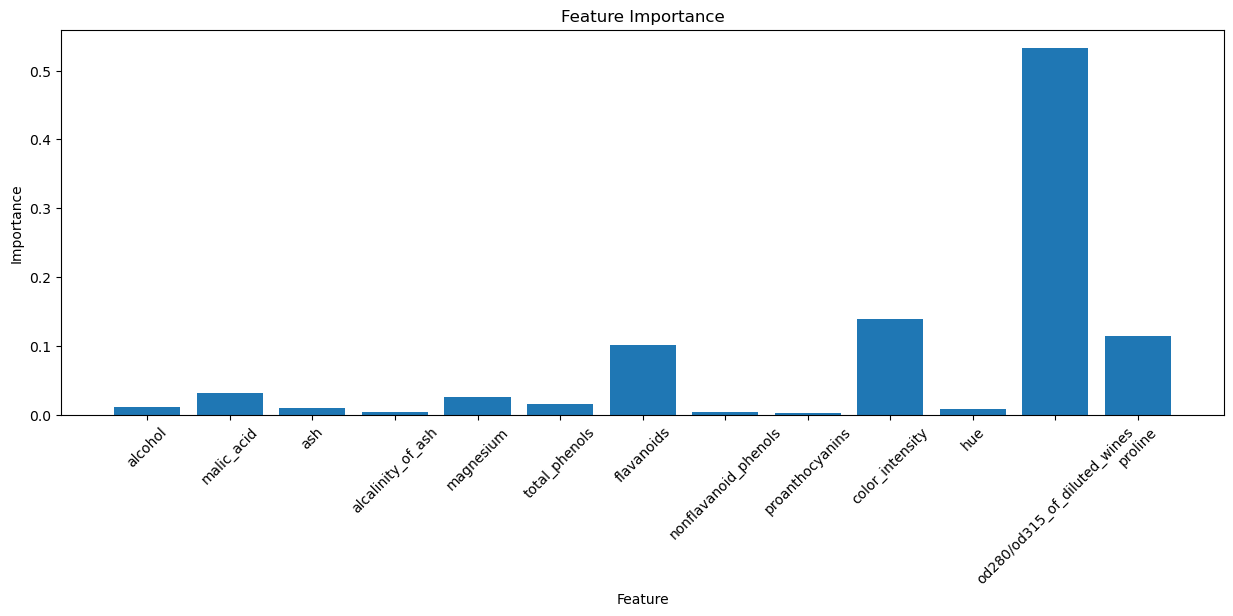

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 파라미터 튜닝
parameters = {
    "max_depth" : [3, 5, 7, 9, 15],
    "learning_rate" : [0.1, 0.01, 0.001],
    "n_estimators" : [50, 100, 200, 300]
    }

# HyperParameter Tuning 및 Fitting
xgb_model = XGBClassifier(random_state = 42)

# 핵심 (cv = 5 : 전체 데이터셋을 5개로 분리하고 train test를 4개와 1개로 분류)
xgb_grid_search = GridSearchCV(estimator = xgb_model, param_grid = parameters, cv = 5, scoring = "accuracy", n_jobs = -1)

# HyperParameter를 찾고, 이를 통해 Fitting을 모두 수행
xgb_grid_search.fit(train_X, train_y)

print("Best Parameters:", xgb_grid_search.best_params_)
print("Best accuracy:", xgb_grid_search.best_score_ )


# 최적화된 하이퍼 파라미터를 XGB 모델에 적용
best_xgb = xgb_grid_search.best_estimator_
xgb_pred = best_xgb.predict(test_X)
xgb_acc = accuracy_score(test_y, xgb_pred)


# Feature Importance 시각화
importances = best_xgb.feature_importances_
features = X.columns

plt.figure(figsize=(15, 5))
plt.bar(features, importances)
plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()
